# Веса показателей образования и экспертизы

Сравниваем **максимизацию дисперсии** и **CRITIC** для образовательной компоненты.
Единица оценки — компания; два эксперимента: вся команда и только CEO за 2024 год.
Равные веса используются как база сравнения. Итоговый индекс репутации из пяти
компонент здесь не рассчитывается.

Порядок: **фиксированная шкала каждого человека → среднее компании → подбор весов**.
Теоретические границы дамми — 0 и 1. Для количеств и стажа задаются искусственные
границы до подбора весов. Выборочные min/max и квантили для нормировки не используются.
Границы одинаковы для двух выборок.

Расчётные функции находятся в utils/education_weighting.py. Ячейки выполняются
последовательно; таблицы сохраняются в results/education_index_experiments,
графики — в figs в PDF. Исходные index_data.csv и index_data_ceo.csv не изменяются.

In [1]:
from pathlib import Path
import sys
import json
import hashlib
import platform
import importlib.metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "utils" / "education_weighting.py").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Запустите ноутбук из каталога проекта или notebooks")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.education_weighting import (
    FEATURE_LABELS, QUALITY_COLUMNS, QUANTITATIVE_COLUMNS,
    education_matrix, fixed_bounds, experiment, critic_weights,
    max_variance_weights, bootstrap_weights,
)

OUT = ROOT / "results" / "education_index_experiments"
FIGS = ROOT / "figs"
OUT.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_rows", 40)
pd.set_option("display.max_columns", 12)
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10, "figure.dpi": 110})

METHOD_LABELS = {
    "equal": "Равные веса", "critic": "CRITIC",
    "max_variance": "Максимум дисперсии",
    "max_variance_capped": "Максимум дисперсии с пределом",
}
DATASET_LABELS = {"all_managers": "Вся команда", "ceo": "Только CEO"}

def save_table(frame, filename, *, index=True):
    frame.to_csv(OUT / filename, index=index, encoding="utf-8-sig")

## Данные и включение компаний

Нужны персональные признаки из index_audit/education_people.csv, созданного
scripts/build_index_data.py. Готовые средние из index_data*.csv недостаточны:
после ограничения выбросов среднее нормированных значений не равно нормированному
среднему. Например, при границе 100 публикаций значения 0 и 200 дают среднее 0.5,
тогда как ограничение их среднего дало бы 1.

Пять компаний без подтверждённого CEO остаются вне оценки CEO; их признаки не
заменяются нулями. Пропуски отдельных персональных количеств сохраняются, и среднее
по компании считается по наблюдаемым значениям. Если показатель отсутствует у всех
людей компании, расчёт останавливается; альтернативу заполнения нулём нужно явно
включить в MISSING_POLICY. Число наблюдений по каждому признаку сохраняется.

In [2]:
INPUT = ROOT / "index_audit" / "education_people.csv"
if not INPUT.exists():
    raise FileNotFoundError("Сначала выполните .venv/bin/python scripts/build_index_data.py")
people = pd.read_csv(INPUT, encoding="utf-8-sig", dtype={"is_ceo": "boolean"})
assert not people[["ticker", "name"]].isna().any().any()
assert not people.duplicated(["ticker", "name"]).any()
assert not people.is_ceo.isna().any()

all_tickers = sorted(people.ticker.unique())
ceo_tickers = sorted(people.loc[people.is_ceo, "ticker"].unique())
no_ceo = sorted(set(all_tickers) - set(ceo_tickers))
sample_audit = pd.DataFrame([
    {"sample": "all_managers", "people": len(people), "companies": len(all_tickers)},
    {"sample": "ceo", "people": int(people.is_ceo.sum()), "companies": len(ceo_tickers)},
])
display(sample_audit)
print("Без подтверждённого CEO:", ", ".join(no_ceo))
save_table(sample_audit, "sample_audit.csv", index=False)
save_table(pd.DataFrame({"ticker": no_ceo, "reason": "no_confirmed_ceo_2024"}),
           "excluded_ceo_companies.csv", index=False)

,sample,people,companies
0,all_managers,1123,110
1,ceo,105,105


Без подтверждённого CEO: BANEP, CBOM, CHMK, LKOH, OZON


## Состав показателей

Три служебных флага — неизвестный уровень образования и неполнота количеств
публикаций/патентов — не получают веса. Счётчики людей, старый expertise_score,
медиа, награды, визуальная оценка и коммуникация также не входят в матрицу критериев.

Четыре взаимоисключающие дамми уровня образования заменяются тремя накопительными:
**бакалавриат и выше**, **магистратура/специалитет и выше**, **учёная степень**.
Среднее и неподтверждённый уровень служат базой. Это не позволяет баллу уменьшаться
при замене бакалавриата на магистратуру или научную степень при прочих равных.
Это осознанный способ кодирования, а не дополнительное свидетельство образования.

Остальные признаки остаются отдельными. В этой экспериментальной спецификации
все 21 критерий считаются стимуляторами: больше — выше балл. Это допущение,
особенно для специальностей и стажа, следует обсуждать содержательно. Веса
показывают статистическую информативность в выбранной выборке, а не причинное
влияние на репутацию. Сильная корреляция показателей релевантного стажа сохраняется
и учитывается в CRITIC; она не устраняется автоматически.

In [3]:
# Редактируемые настройки; границы не оцениваются по min/max выборки.
MAX_WEIGHT = 0.20
BOOTSTRAP_REPETITIONS = 200
SEED = 42
MISSING_POLICY = "preserve"      # preserve / zero / raise
ENCODING = "cumulative"

feature_matrix = education_matrix(people, encoding=ENCODING)
BOUNDS = fixed_bounds(feature_matrix.columns)
# Искусственные границы можно изменить здесь, например:
# BOUNDS.loc["publications_count", "upper"] = 150.0

bounds_display = BOUNDS.assign(label=BOUNDS.index.map(FEATURE_LABELS))
display(bounds_display[["label", "lower", "upper", "bound_type"]])
save_table(bounds_display, "normalization_bounds.csv")
print("Критериев:", len(BOUNDS))

,label,lower,upper,bound_type
feature,,,,
education_bachelor_or_higher,Бакалавриат и выше,0.0,1.0,theoretical
education_master_or_higher,Магистратура / специалитет и выше,0.0,1.0,theoretical
education_doctoral,Учёная степень,0.0,1.0,theoretical
has_mba_emba,MBA / EMBA,0.0,1.0,theoretical
has_foreign_education,Зарубежное образование,0.0,1.0,theoretical
has_professional_retraining,Профессиональная переподготовка,0.0,1.0,theoretical
has_law_education,Юридическое образование,0.0,1.0,theoretical
has_economics_education,Экономическое образование,0.0,1.0,theoretical
publications_count,Количество публикаций,0.0,100.0,artificial


Критериев: 21


## Нормировка до агрегирования

Для персонального показателя $x_{ij}$ с заданными границами $L_j,U_j$:

$$z_{ij}=\frac{\operatorname{clip}(x_{ij},L_j,U_j)-L_j}{U_j-L_j}.$$

Для дамми $L=0,U=1$ — теоретические границы. Нарушение этих границ вызывает ошибку.
Для остальных критериев нижняя граница 0, верхняя — искусственная и редактируемая:
100 публикаций, 20 патентов, 40 лет исследований, 60 лет в том же секторе/отрасли/
отраслевой группе, 100 лет общего опыта и 50 лет в компании. Эти числа — стартовые
допущения, не оценки из данных и не установленные научные нормативы. Продолжительности
складывают пересекающиеся эпизоды и могут превышать длину календарной карьеры.
Значения выше искусственного порога получают 1; число таких случаев сохраняется.

После этого $\bar z_{cj}$ — среднее по людям компании. Веса подбираются по матрице
$\bar Z$: каждая компания имеет одинаковый вес независимо от числа её менеджеров.
Далее индекс **образовательной компоненты** равен $100\bar Z w$.

Дополнительный эксперимент log1p использует те же фиксированные границы:
$\log(1+\operatorname{clip}(x,0,U))/\log(1+U)$. Он применяется только к количествам
и стажу. Проверка порогов 0.5× и 2× также выполняет нормировку людей заново.

## Максимизация дисперсии: ограничения принципиальны

$$\max_w\operatorname{Var}(\bar Z w)=w^\top\Sigma w,\qquad w_j\geq0,\quad\sum_jw_j=1.$$

Без ограничения масштаба весов задача не ограничена сверху. На симплексе ковариационная
матрица положительно полуопределена, поэтому целевая функция выпукла и её максимум
достигается в вершине. Более того,
$w^\top\Sigma w\leq\sum_jw_j\Sigma_{jj}\leq\max_j\Sigma_{jj}$.
Следовательно, существует оптимум с весом 1 у единственного критерия с максимальной
дисперсией. При нескольких оптимумах используется первая вершина в порядке колонок;
количество равноценных вершин показывается в диагностике.

**Дополнительная спецификация:** $0\leq w_j\leq0.20$, $\sum_jw_j=1$.
Предел 20% — явное ограничение концентрации, а не следствие метода. Перебираются
все вершины ограниченного симплекса; так находится глобальный максимум.
При пределе 20% оптимальная вершина содержит пять весов по 20%. Это не означает,
что остальные показатели содержательно бесполезны. Вариант PCA с ограничением
$\|w\|_2=1$ решает другую задачу и может давать отрицательные веса; здесь он не
подменяет задачу неотрицательного индекса.

## CRITIC

Для нормированных критериев используются стандартное отклонение и корреляция Пирсона:

$$C_j=\sigma_j\sum_k(1-r_{jk}),\qquad w_j=\frac{C_j}{\sum_\ell C_\ell}.$$

Используется $1-r$, **не** $1-|r|$. Постоянные критерии исключаются из корреляционной
матрицы и получают нулевой вес. Если сумма информации равна нулю, веса не определены:
код выдаёт ошибку, не подставляя равные веса. Используется ddof=1; общий множитель
стандартных отклонений не меняет нормированные веса.

Источник: Diakoulaki, D., Mavrotas, G., & Papayannakis, L. (1995).
*Determining objective weights in multiple criteria problems: The CRITIC method*.
Computers & Operations Research, 22(7), 763–770.
[DOI](https://doi.org/10.1016/0305-0548%2894%2900059-H),
[полный текст](https://reformship.github.io/pages/1capacity/1model/11evaluation/Determining%20objective%20weights%20in%20multiple%20criteria%20problems%20The%20CRITIC%20method.pdf).
Формула весов следует статье; фиксированные границы вместо выборочных экстремумов —
адаптация нормировки по условию этой задачи.

In [4]:
# Численная проверка по опубликованной нормированной таблице 2 и весам таблицы 3.
# Эти значения нужны только для проверки CRITIC; они не задают шкалу наших данных.
paper_z = pd.DataFrame({
    "profitability": [1, .578, .524, .455, .418, .404, .298, 0],
    "market_share": [.212, 0, .446, .785, .650, 1, .845, .790],
    "productivity": [.996, 1, .460, .200, .401, .069, .335, 0],
})
paper_weights, _ = critic_weights(paper_z)
np.testing.assert_allclose(paper_weights, [.202, .481, .317], atol=.001)
display(pd.DataFrame({"computed": paper_weights, "paper_table_3": [.202, .481, .317]}))

,computed,paper_table_3
profitability,0.202047,0.202
market_share,0.481220,0.481
productivity,0.316733,0.317


## Основные эксперименты

Шкалы совпадают; веса оцениваются отдельно для всей команды и CEO. Различия весов
поэтому отражают как состав людей, так и отсутствие пяти компаний в CEO-выборке.
Неопределённость исходной информации не исчезает после нормировки: частота
пропусков и флаги неполноты сохраняются отдельно в аудите.

In [5]:
results = {
    sample: experiment(people, ceo_only=(sample == "ceo"), encoding=ENCODING,
                       bounds=BOUNDS, missing=MISSING_POLICY, upper_bound=MAX_WEIGHT)
    for sample in DATASET_LABELS
}
for sample, result in results.items():
    w, z = result["weights"], result["normalized"]
    np.testing.assert_allclose(w.sum(), 1, atol=1e-12)
    assert w.ge(-1e-12).all().all()
    assert w.max_variance_capped.max() <= MAX_WEIGHT + 1e-12
    assert z.ge(0).all().all() and z.le(1).all().all()
    summary = result["summary"]
    assert summary.loc["max_variance", "index_variance"] + 1e-9 >= summary.index_variance.max()
    if 1 / z.std().gt(1e-12).sum() <= MAX_WEIGHT:
        assert summary.loc["max_variance_capped", "index_variance"] + 1e-9 >= summary.loc["equal", "index_variance"]
    for name in ["weights", "normalized", "coverage", "preprocessing", "critic_details", "summary", "rank_correlations"]:
        save_table(result[name], f"{sample}_{name}.csv")
    save_table(result["scores"].add_prefix("education_index_"), f"{sample}_scores.csv")
    display(Markdown(f"### {DATASET_LABELS[sample]}"))
    display(result["weights"].assign(label=lambda x: x.index.map(FEATURE_LABELS))
            .sort_values("critic", ascending=False))

### Вся команда

,equal,critic,max_variance,max_variance_capped,label
feature,,,,,
has_foreign_education,0.047619,0.086239,0.0,0.2,Зарубежное образование
has_economics_education,0.047619,0.083127,0.0,0.2,Экономическое образование
education_bachelor_or_higher,0.047619,0.081958,1.0,0.2,Бакалавриат и выше
education_master_or_higher,0.047619,0.081078,0.0,0.2,Магистратура / специалитет и выше
has_mba_emba,0.047619,0.077803,0.0,0.2,MBA / EMBA
has_other_company_management,0.047619,0.071473,0.0,0.0,Управление другой компанией
education_doctoral,0.047619,0.064613,0.0,0.0,Учёная степень
has_research_experience,0.047619,0.062118,0.0,0.0,Наличие исследовательского опыта
has_law_education,0.047619,0.047568,0.0,0.0,Юридическое образование


### Только CEO

,equal,critic,max_variance,max_variance_capped,label
feature,,,,,
has_economics_education,0.047619,0.091649,1.0,0.2,Экономическое образование
has_foreign_education,0.047619,0.087742,0.0,0.0,Зарубежное образование
education_master_or_higher,0.047619,0.080564,0.0,0.2,Магистратура / специалитет и выше
has_other_company_management,0.047619,0.079926,0.0,0.0,Управление другой компанией
education_bachelor_or_higher,0.047619,0.079079,0.0,0.2,Бакалавриат и выше
has_mba_emba,0.047619,0.078230,0.0,0.0,MBA / EMBA
education_doctoral,0.047619,0.075671,0.0,0.2,Учёная степень
has_research_experience,0.047619,0.066024,0.0,0.2,Наличие исследовательского опыта
has_law_education,0.047619,0.063542,0.0,0.0,Юридическое образование


In [6]:
# Где ограничение искусственной шкалы меняет исходные значения.
scale_audit = pd.concat({sample: r["preprocessing"] for sample, r in results.items()}, names=["sample"])
display(scale_audit.loc[(scale_audit.above_upper_count > 0) | (scale_audit.missing_count > 0),
                       ["upper", "bound_type", "missing_count", "above_upper_count"]])
company_active = pd.concat({sample: r["normalized"].std().gt(1e-12)
                            for sample, r in results.items()}, axis=1)
display(Markdown("**Активность критериев на уровне компаний**"))
display(company_active.rename_axis("feature"))
save_table(scale_audit, "scale_audit.csv")

upper  bound_type  \
sample       feature                                                   
all_managers publications_count                    100.0  artificial   
             research_experience_years              40.0  artificial   
             patents_count                          20.0  artificial   
             experience_years_same_sector           60.0  artificial   
             experience_years_same_industry         60.0  artificial   
             experience_years_same_industry_group   60.0  artificial   
             current_company_experience_years       50.0  artificial   

                                                   missing_count  \
sample       feature                                               
all_managers publications_count                                5   
             research_experience_years                         0   
             patents_count                                     2   
             experience_years_same_sector                      0   
             experience_years_same_industry                    0   
             experience_years_same_industry_group              0   
             current_company_experience_years                  0   

                                                   above_upper_count  
sample       feature                                                  
all_managers publications_count                                    9  
             research_experience_years                             4  
             patents_count                                         2  
             experience_years_same_sector                          2  
             experience_years_same_industry                        2  
             experience_years_same_industry_group                  2  
             current_company_experience_years                      4

**Активность критериев на уровне компаний**

,all_managers,ceo
feature,,
education_bachelor_or_higher,True,True
education_master_or_higher,True,True
education_doctoral,True,True
has_mba_emba,True,True
has_foreign_education,True,True
has_professional_retraining,True,True
has_law_education,True,True
has_economics_education,True,True
publications_count,True,True


In [7]:
# Стандартное отклонение, конфликт и количество информации CRITIC.
critic_diagnostics = pd.concat({s: r["critic_details"] for s, r in results.items()}, names=["sample"])
display(critic_diagnostics.sort_values(["weight"], ascending=False).head(16))
optimizer_diagnostics = pd.DataFrame([
    {"sample": sample, "method": method, **diagnostic}
    for sample, result in results.items() for method, diagnostic in result["diagnostics"].items()
])
display(optimizer_diagnostics)
save_table(optimizer_diagnostics, "variance_optimization_diagnostics.csv", index=False)

std   conflict  information  \
sample       feature                                                          
ceo          has_economics_education       0.501828  17.676762     8.870697   
             has_foreign_education         0.427960  19.844164     8.492518   
all_managers has_foreign_education         0.266230  18.292260     4.869940   
             has_economics_education       0.306728  15.304243     4.694238   
             education_bachelor_or_higher  0.334858  13.821348     4.628195   
             education_master_or_higher    0.334677  13.680448     4.578528   
ceo          education_master_or_higher    0.480003  16.245263     7.797776   
             has_other_company_management  0.394560  19.606559     7.735965   
             education_bachelor_or_higher  0.466457  16.408794     7.654002   
             has_mba_emba                  0.386825  19.574279     7.571824   
all_managers has_mba_emba                  0.237630  18.489129     4.393577   
ceo          education_doctoral            0.427960  17.114150     7.324180   
all_managers has_other_company_management  0.230148  17.537003     4.036109   
ceo          has_research_experience       0.370130  17.265472     6.390472   
all_managers education_doctoral            0.206754  17.647667     3.648731   
ceo          has_law_education             0.307715  19.986583     6.150175   

                                             weight  
sample       feature                                 
ceo          has_economics_education       0.091649  
             has_foreign_education         0.087742  
all_managers has_foreign_education         0.086239  
             has_economics_education       0.083127  
             education_bachelor_or_higher  0.081958  
             education_master_or_higher    0.081078  
ceo          education_master_or_higher    0.080564  
             has_other_company_management  0.079926  
             education_bachelor_or_higher  0.079079  
             has_mba_emba                  0.078230  
all_managers has_mba_emba                  0.077803  
ceo          education_doctoral            0.075671  
all_managers has_other_company_management  0.071473  
ceo          has_research_experience       0.066024  
all_managers education_doctoral            0.064613  
ceo          has_law_education             0.063542

,sample,method,variance,upper_bound,vertices_evaluated,optimal_vertices,tie_rule,global_optimum
0,all_managers,max_variance,0.112130,1.0,21,1,"first in input feature order; ties reported, n...",True
1,all_managers,max_variance_capped,0.045044,0.2,20349,1,"first in input feature order; ties reported, n...",True
2,ceo,max_variance,0.251832,1.0,21,1,"first in input feature order; ties reported, n...",True
3,ceo,max_variance_capped,0.101560,0.2,20349,1,"first in input feature order; ties reported, n...",True


## Сравнение весов и результатов

Дисперсия относится к образовательному индексу в шкале 0–100. Число эффективных
показателей равно $1/\sum_j w_j^2$. Большая дисперсия — свойство выбранной
математической цели; сама по себе она не подтверждает качество измерения репутации.

index_variance  index_std  nonzero_weights  \
sample       method                                                            
all_managers equal                     78.786765   8.876191               21   
             critic                   143.796116  11.991502               21   
             max_variance            1121.301732  33.485844                1   
             max_variance_capped      450.435965  21.223477                5   
ceo          equal                    124.470128  11.156618               21   
             critic                   268.094433  16.373589               21   
             max_variance            2518.315018  50.182816                1   
             max_variance_capped     1015.604396  31.868549                5   

                                  max_weight  effective_features  
sample       method                                               
all_managers equal                  0.047619           21.000000  
             critic                 0.086239           16.487549  
             max_variance           1.000000            1.000000  
             max_variance_capped    0.200000            5.000000  
ceo          equal                  0.047619           21.000000  
             critic                 0.091649           15.507430  
             max_variance           1.000000            1.000000  
             max_variance_capped    0.200000            5.000000

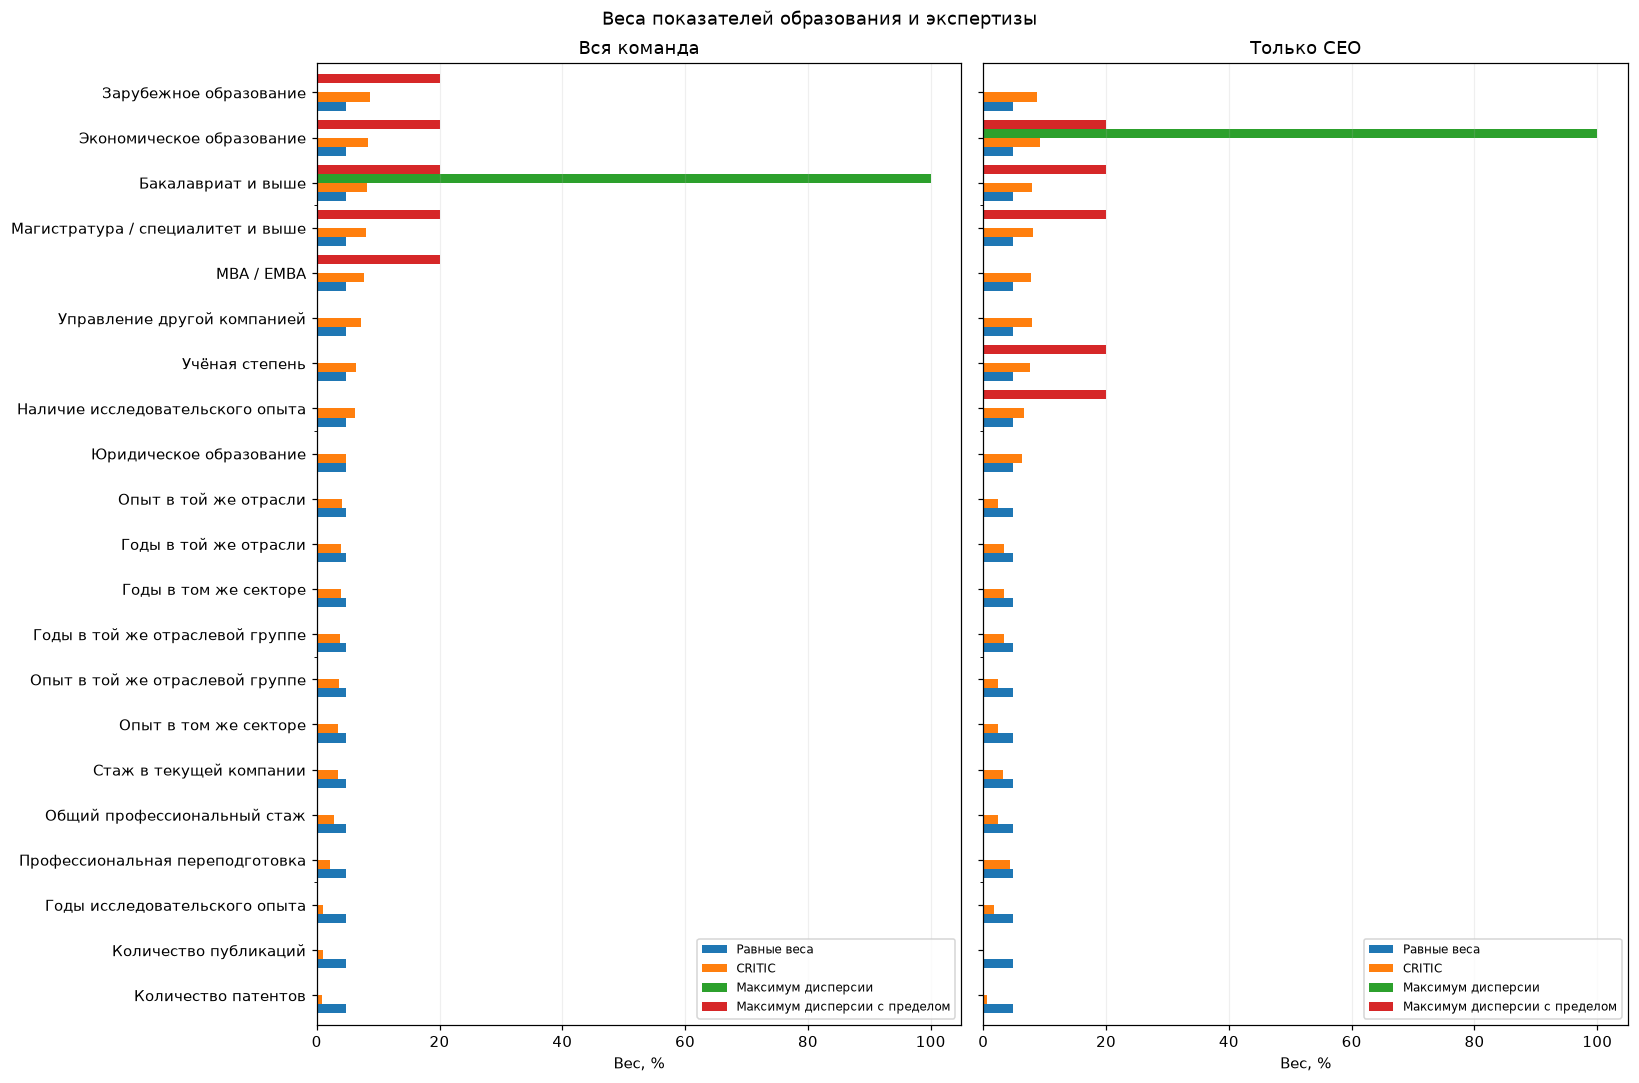

In [8]:
summary = pd.concat({s: r["summary"] for s, r in results.items()}, names=["sample"])
display(summary)
save_table(summary, "methods_summary.csv")

order = results["all_managers"]["weights"].critic.sort_values().index
fig, axes = plt.subplots(1, 2, figsize=(15, 10), sharey=True)
for ax, (sample, result) in zip(axes, results.items()):
    values = result["weights"].reindex(order).rename(columns=METHOD_LABELS) * 100
    values.index = values.index.map(FEATURE_LABELS)
    values.plot.barh(ax=ax, width=.8)
    ax.set(title=DATASET_LABELS[sample], xlabel="Вес, %", ylabel="")
    ax.grid(axis="x", alpha=.2)
    ax.legend(fontsize=8, loc="lower right")
fig.suptitle("Веса показателей образования и экспертизы")
fig.tight_layout()
fig.savefig(FIGS / "education_index_weights_comparison.pdf", bbox_inches="tight")
plt.show()

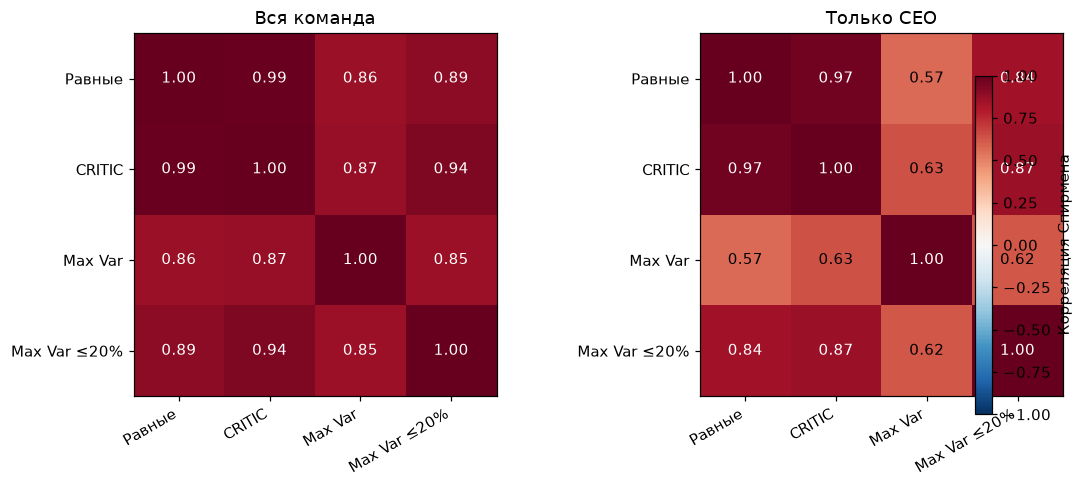

**Вся команда: 10 наибольших баллов CRITIC**

,equal,critic,max_variance,max_variance_capped,rank_critic
ticker,,,,,
CBOM,58.381,72.542,100.0,80.000,1.0
MBNK,55.810,69.458,100.0,100.000,2.0
CHMF,53.508,67.649,100.0,100.000,3.0
APTK,50.452,62.474,100.0,80.000,4.0
AGRO,45.857,61.530,100.0,100.000,5.0
FIVE,44.935,57.194,100.0,80.000,6.0
BSPB,50.952,55.952,100.0,60.000,7.0
LKOH,50.143,55.612,100.0,60.000,8.0
ETLN,43.381,54.749,100.0,68.571,9.0


**Только CEO: 10 наибольших баллов CRITIC**

,equal,critic,max_variance,max_variance_capped,rank_critic
ticker,,,,,
SVAV,66.571,80.708,100.0,100.0,1.0
MBNK,55.810,65.730,100.0,60.0,2.0
DIAS,58.952,65.376,100.0,100.0,3.0
FESH,53.881,64.910,100.0,100.0,4.0
ETLN,49.571,63.708,100.0,100.0,5.0
CHMF,51.492,62.786,100.0,60.0,6.0
MVID,51.667,62.538,100.0,60.0,7.0
APTK,50.452,59.637,100.0,80.0,8.0
GEMC,46.952,59.555,100.0,60.0,9.0


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
short_labels = ["Равные", "CRITIC", "Max Var", "Max Var ≤20%"]
for ax, (sample, result) in zip(axes, results.items()):
    corr = result["rank_correlations"]
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(corr)), short_labels, rotation=30, ha="right")
    ax.set_yticks(range(len(corr)), short_labels)
    ax.set_title(DATASET_LABELS[sample])
    for i in range(len(corr)):
        for j in range(len(corr)):
            value = corr.iloc[i,j]
            ax.text(j,i,f"{value:.2f}",ha="center",va="center",
                    color="white" if abs(value) > .65 else "black")
fig.colorbar(im, ax=axes.ravel().tolist(), label="Корреляция Спирмена", shrink=.8)
fig.subplots_adjust(bottom=.22, wspace=.45, right=.85)
fig.savefig(FIGS / "education_index_rank_correlations.pdf", bbox_inches="tight")
plt.show()

for sample, result in results.items():
    display(Markdown(f"**{DATASET_LABELS[sample]}: 10 наибольших баллов CRITIC**"))
    scores = result["scores"].copy()
    scores["rank_critic"] = scores.critic.rank(ascending=False, method="min")
    display(scores.sort_values("critic", ascending=False).head(10).round(3))

In [10]:
# Веса на одной шкале, но в разных выборках компаний и людей.
weight_comparison = pd.DataFrame({
    "all_managers_critic": results["all_managers"]["weights"].critic,
    "ceo_critic": results["ceo"]["weights"].critic,
})
weight_comparison["difference_ceo_minus_all"] = weight_comparison.ceo_critic - weight_comparison.all_managers_critic
weight_comparison["label"] = weight_comparison.index.map(FEATURE_LABELS)
display(weight_comparison.sort_values("difference_ceo_minus_all", key=abs, ascending=False))
save_table(weight_comparison, "critic_weights_cohort_comparison.csv")

,all_managers_critic,ceo_critic,difference_ceo_minus_all,label
feature,,,,
has_professional_retraining,0.021865,0.043488,0.021623,Профессиональная переподготовка
has_experience_same_industry,0.041333,0.024379,-0.016955,Опыт в той же отрасли
has_law_education,0.047568,0.063542,0.015973,Юридическое образование
has_experience_same_industry_group,0.036936,0.024379,-0.012558,Опыт в той же отраслевой группе
education_doctoral,0.064613,0.075671,0.011058,Учёная степень
publications_count,0.010981,0.000775,-0.010206,Количество публикаций
has_experience_same_sector,0.034357,0.024379,-0.009978,Опыт в том же секторе
has_economics_education,0.083127,0.091649,0.008522,Экономическое образование
has_other_company_management,0.071473,0.079926,0.008453,Управление другой компанией


## Чувствительность к искусственным границам и форме шкалы

Меняем только искусственные верхние границы, оставляя теоретические 0–1 неизменными.
Для каждого сценария заново нормируем **людей**, затем агрегируем и оцениваем веса.
Сравниваем изменение весов (L1) и рангов относительно основного сценария.
Сценарий log1p использует те же исходные границы и меняет только форму количественной
шкалы. Здесь нет оптимизации порогов под желаемые веса или ранги.

In [11]:
sensitivity_rows, sensitivity_weights = [], []
scenarios = [("caps_x0.5", .5, "none"), ("baseline", 1, "none"),
             ("caps_x2", 2, "none"), ("log1p_fixed_caps", 1, "log1p")]
for sample, baseline in results.items():
    for scenario, multiplier, transform in scenarios:
        bounds = BOUNDS.copy()
        artificial = bounds.bound_type.eq("artificial")
        bounds.loc[artificial, "upper"] *= multiplier
        result = baseline if scenario == "baseline" else experiment(
            people, ceo_only=(sample == "ceo"), bounds=bounds, transform=transform,
            upper_bound=MAX_WEIGHT, missing=MISSING_POLICY, encoding=ENCODING)
        for method in result["weights"]:
            w = result["weights"][method]
            sensitivity_rows.append({
                "sample": sample, "scenario": scenario, "method": method,
                "weight_L1_from_baseline": (w - baseline["weights"][method]).abs().sum(),
                "rank_spearman_from_baseline": result["scores"][method].corr(baseline["scores"][method], method="spearman"),
                "largest_weight": w.max(), "leading_feature": w.idxmax(),
                "index_variance": result["scores"][method].var(),
            })
            sensitivity_weights.extend({"sample": sample, "scenario": scenario, "method": method,
                                        "feature": feature, "weight": value} for feature, value in w.items())
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.loc[sensitivity.method.isin(["critic", "max_variance_capped"])])
save_table(sensitivity, "scale_sensitivity.csv", index=False)
save_table(pd.DataFrame(sensitivity_weights), "scale_sensitivity_weights.csv", index=False)

,sample,scenario,method,weight_L1_from_baseline,rank_spearman_from_baseline,largest_weight,leading_feature,index_variance
1,all_managers,caps_x0.5,critic,0.174836,0.978270,0.077549,has_foreign_education,173.799350
3,all_managers,caps_x0.5,max_variance_capped,1.200000,0.731599,0.200000,education_bachelor_or_higher,590.921143
5,all_managers,baseline,critic,0.000000,1.000000,0.086239,has_foreign_education,143.796116
7,all_managers,baseline,max_variance_capped,0.000000,1.000000,0.200000,education_bachelor_or_higher,450.435965
9,all_managers,caps_x2,critic,0.174652,0.990776,0.095878,has_foreign_education,148.416734
11,all_managers,caps_x2,max_variance_capped,0.000000,1.000000,0.200000,education_bachelor_or_higher,450.435965
13,all_managers,log1p_fixed_caps,critic,0.119876,0.992102,0.081687,has_foreign_education,156.631479
15,all_managers,log1p_fixed_caps,max_variance_capped,0.800000,0.884547,0.200000,education_bachelor_or_higher,515.072363
17,ceo,caps_x0.5,critic,0.174325,0.966629,0.081130,has_economics_education,268.004867
19,ceo,caps_x0.5,max_variance_capped,0.000000,1.000000,0.200000,education_bachelor_or_higher,1015.604396


## Чувствительность к пределу веса

Сравниваем разные ограничения концентрации на одной нормированной матрице.
Перебор вершин даёт глобальный максимум для каждого ограничения; поиск с локальным
оптимизатором не выдаётся за доказанный максимум. При изменении настроек слишком
большой перебор останавливается с явной ошибкой.

In [12]:
cap_rows = []
for sample, result in results.items():
    for cap in sorted(set([1.0, .5, .25, MAX_WEIGHT]), reverse=True):
        w, diagnostic = max_variance_weights(result["normalized"], upper_bound=cap)
        cap_rows.append({"sample": sample, "cap": cap, "index_variance": 10000 * diagnostic["variance"],
                         "nonzero_weights": int(w.gt(1e-12).sum()),
                         "selected_features": "; ".join(w.index[w.gt(1e-12)]),
                         "vertices_evaluated": diagnostic["vertices_evaluated"],
                         "optimal_vertices": diagnostic["optimal_vertices"]})
cap_sensitivity = pd.DataFrame(cap_rows)
display(cap_sensitivity)
save_table(cap_sensitivity, "weight_cap_sensitivity.csv", index=False)

,sample,cap,index_variance,nonzero_weights,selected_features,vertices_evaluated,optimal_vertices
0,all_managers,1.00,1121.301732,1,education_bachelor_or_higher,21,1
1,all_managers,0.50,1100.981635,2,education_bachelor_or_higher; education_master...,210,1
2,all_managers,0.25,570.324622,4,education_bachelor_or_higher; education_master...,5985,1
3,all_managers,0.20,450.435965,5,education_bachelor_or_higher; education_master...,20349,1
4,ceo,1.00,2518.315018,1,has_economics_education,21,1
5,ceo,0.50,2147.435897,2,education_bachelor_or_higher; education_master...,210,1
6,ceo,0.25,1292.353480,4,education_bachelor_or_higher; education_master...,5985,1
7,ceo,0.20,1015.604396,5,education_bachelor_or_higher; education_master...,20349,1


## Устойчивость весов: bootstrap компаний

Повторно выбираем компании с возвращением при фиксированных границах и уже
нормированных персональных данных. Это условная устойчивость к составу компаний,
а не доверительный интервал для «истинной важности» признака и не оценка ошибок
в первичных биографиях. Наблюдения людей внутри компаний отдельно не пересэмплируются.

Оцениваются CRITIC и максимум дисперсии без верхнего ограничения веса.
Для последнего средние bootstrap-веса означают частоту выбора критерия,
а не решение новой задачи максимизации дисперсии. Все неудачные повторения
регистрируются; они не заменяются произвольными весами.

In [13]:
bootstrap_parts, bootstrap_failures = [], []
for sample, result in results.items():
    draws, failures = bootstrap_weights(result["normalized"], repetitions=BOOTSTRAP_REPETITIONS, seed=SEED)
    bootstrap_parts.append(draws.assign(sample=sample))
    bootstrap_failures.append(failures.assign(sample=sample))
bootstrap_draws = pd.concat(bootstrap_parts, ignore_index=True)
bootstrap_failed = pd.concat(bootstrap_failures, ignore_index=True)
bootstrap_summary = bootstrap_draws.groupby(["sample", "method", "feature"]).weight.agg(
    mean="mean", std="std", p025=lambda x: x.quantile(.025), p975=lambda x: x.quantile(.975),
    selection_frequency=lambda x: x.gt(1e-12).mean(), successful_repetitions="count",
)
display(bootstrap_summary.xs("max_variance", level="method")
        .sort_values("selection_frequency", ascending=False).head(12))
print("Неудачных повторений:", len(bootstrap_failed))
save_table(bootstrap_summary, "bootstrap_summary.csv")
save_table(bootstrap_draws, "bootstrap_draws.csv", index=False)
save_table(bootstrap_failed, "bootstrap_failures.csv", index=False)

mean       std   p025  \
sample       feature                                                        
ceo          has_economics_education               0.975  0.156517  0.975   
all_managers education_bachelor_or_higher          0.500  0.501255  0.000   
             education_master_or_higher            0.420  0.494797  0.000   
             has_economics_education               0.070  0.255787  0.000   
ceo          education_master_or_higher            0.025  0.156517  0.000   
all_managers has_foreign_education                 0.010  0.099748  0.000   
ceo          has_research_experience               0.000  0.000000  0.000   
             has_experience_same_industry_group    0.000  0.000000  0.000   
             publications_count                    0.000  0.000000  0.000   
             experience_years_same_industry        0.000  0.000000  0.000   
             experience_years_same_industry_group  0.000  0.000000  0.000   
             experience_years_same_sector          0.000  0.000000  0.000   

                                                    p975  selection_frequency  \
sample       feature                                                            
ceo          has_economics_education               1.000                0.975   
all_managers education_bachelor_or_higher          1.000                0.500   
             education_master_or_higher            1.000                0.420   
             has_economics_education               1.000                0.070   
ceo          education_master_or_higher            0.025                0.025   
all_managers has_foreign_education                 0.000                0.010   
ceo          has_research_experience               0.000                0.000   
             has_experience_same_industry_group    0.000                0.000   
             publications_count                    0.000                0.000   
             experience_years_same_industry        0.000                0.000   
             experience_years_same_industry_group  0.000                0.000   
             experience_years_same_sector          0.000                0.000   

                                                   successful_repetitions  
sample       feature                                                       
ceo          has_economics_education                                  200  
all_managers education_bachelor_or_higher                             200  
             education_master_or_higher                               200  
             has_economics_education                                  200  
ceo          education_master_or_higher                               200  
all_managers has_foreign_education                                    200  
ceo          has_research_experience                                  200  
             has_experience_same_industry_group                       200  
             publications_count                                       200  
             experience_years_same_industry                           200  
             experience_years_same_industry_group                     200  
             experience_years_same_sector                             200

Неудачных повторений: 0


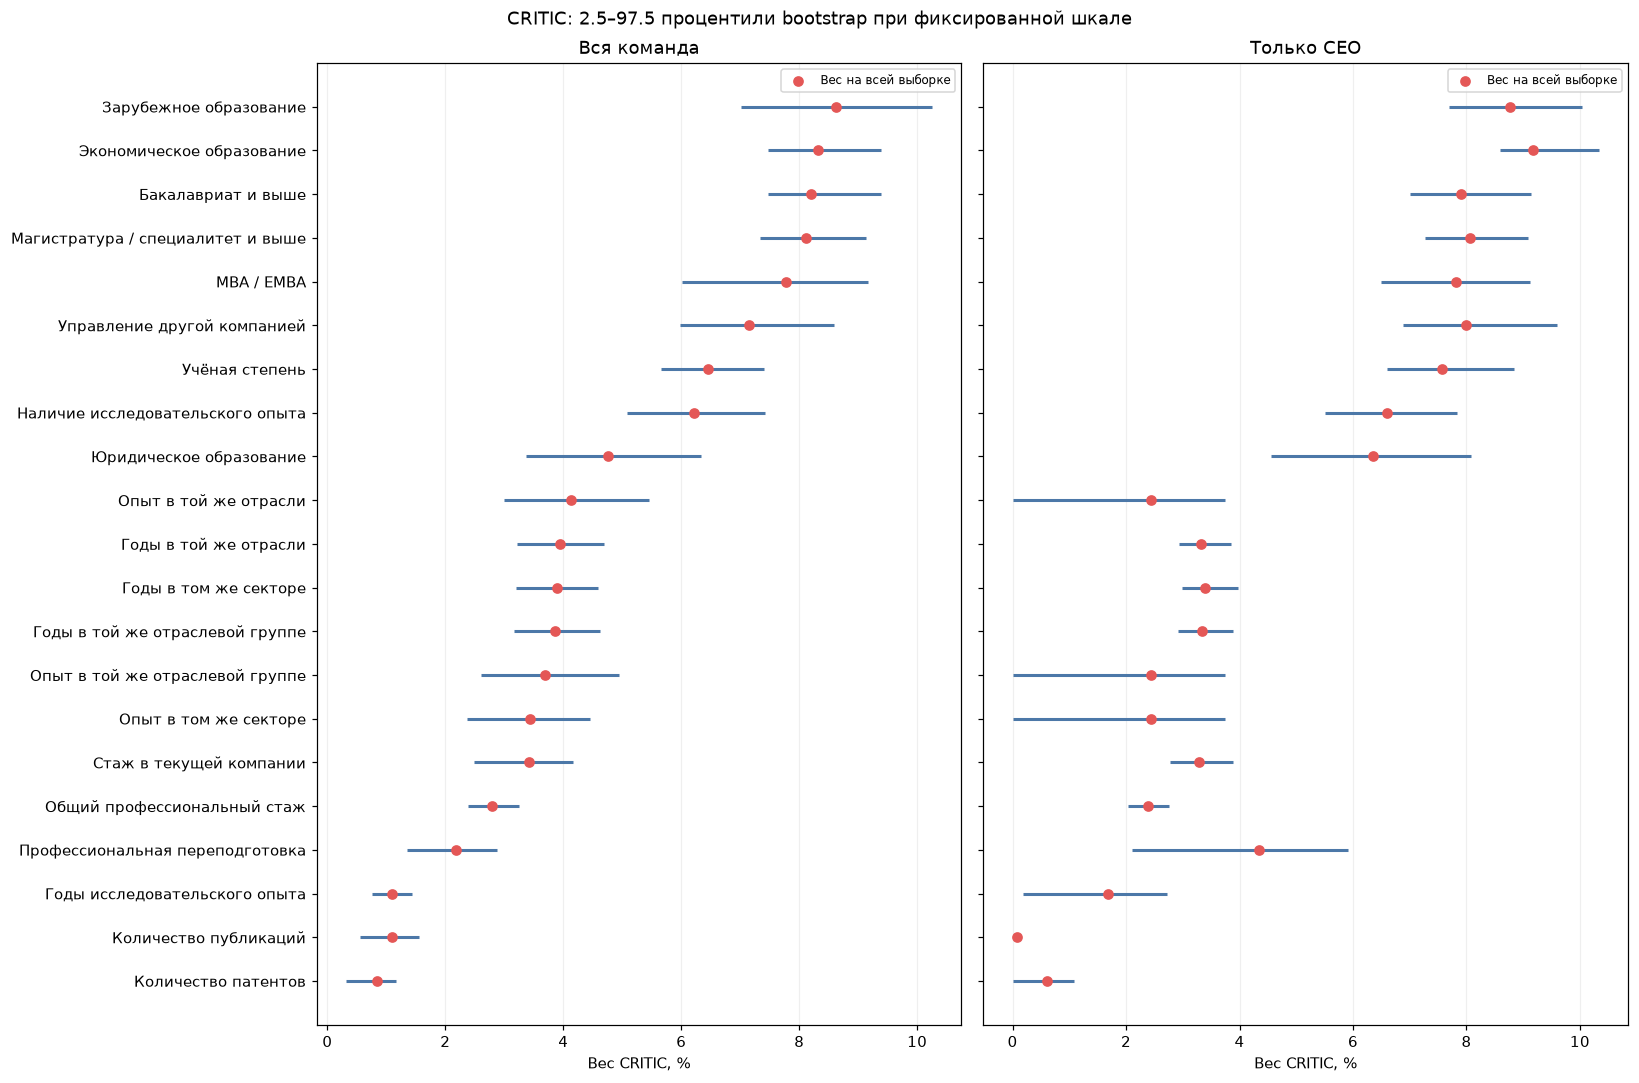

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10), sharey=True)
for ax, (sample, result) in zip(axes, results.items()):
    table = bootstrap_summary.xs((sample, "critic"), level=("sample", "method")).reindex(order)
    y = np.arange(len(table))
    ax.hlines(y, table.p025 * 100, table.p975 * 100, color="#4C78A8", linewidth=2)
    ax.scatter(result["weights"].critic.reindex(order) * 100, y, color="#E45756", zorder=3,
               label="Вес на всей выборке")
    ax.set_yticks(y, [FEATURE_LABELS[f] for f in order])
    ax.set(title=DATASET_LABELS[sample], xlabel="Вес CRITIC, %")
    ax.grid(axis="x", alpha=.2)
    ax.legend(fontsize=8)
fig.suptitle("CRITIC: 2.5–97.5 процентили bootstrap при фиксированной шкале")
fig.tight_layout()
fig.savefig(FIGS / "education_index_critic_bootstrap.pdf", bbox_inches="tight")
plt.show()

## Сохранение настроек и чтение результатов

Сохранённые веса применимы только с тем же составом критериев, кодированием,
границами, обработкой пропусков и порядком «человек → компания». Чтобы воспроизвести
расчёт, используйте сохранённые настройки и проверяйте SHA-256 входного файла.
Файлы scores относятся только к образовательной компоненте, не к общему индексу
репутации. Старый expertise_score не используется как критерий или целевая переменная.

In [15]:
metadata = {
    "input": str(INPUT.relative_to(ROOT)), "input_sha256": hashlib.sha256(INPUT.read_bytes()).hexdigest(),
    "python": platform.python_version(),
    "packages": {name: importlib.metadata.version(name) for name in ["numpy", "pandas", "matplotlib", "scipy"]},
    "encoding": ENCODING, "missing_policy": MISSING_POLICY,
    "normalization_order": "fixed person-level bounds -> company mean -> company-level weights",
    "normalization_bounds": BOUNDS.reset_index().to_dict("records"),
    "maximum_weight_capped_model": MAX_WEIGHT,
    "bootstrap_repetitions": BOOTSTRAP_REPETITIONS, "seed": SEED,
    "no_ceo_companies": no_ceo, "excluded_quality_columns": QUALITY_COLUMNS,
    "critic_reference": "https://doi.org/10.1016/0305-0548(94)00059-H",
    "variance_diagnostics": {s: r["diagnostics"] for s,r in results.items()},
}
(OUT / "experiment_settings.json").write_text(json.dumps(metadata, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")

for sample, result in results.items():
    winner = result["weights"].max_variance.idxmax()
    top = result["weights"].critic.nlargest(3)
    print(DATASET_LABELS[sample])
    print("  Свободный максимум дисперсии:", FEATURE_LABELS[winner])
    print("  Три наибольших веса CRITIC:", "; ".join(f"{FEATURE_LABELS[k]}: {v:.2%}" for k,v in top.items()))
    print("  Эффективное число критериев CRITIC:", round(result["summary"].loc["critic", "effective_features"], 2))
print("Таблицы и настройки:", OUT)
print("Графики:", FIGS)

Вся команда
  Свободный максимум дисперсии: Бакалавриат и выше
  Три наибольших веса CRITIC: Зарубежное образование: 8.62%; Экономическое образование: 8.31%; Бакалавриат и выше: 8.20%
  Эффективное число критериев CRITIC: 16.49
Только CEO
  Свободный максимум дисперсии: Экономическое образование
  Три наибольших веса CRITIC: Экономическое образование: 9.16%; Зарубежное образование: 8.77%; Магистратура / специалитет и выше: 8.06%
  Эффективное число критериев CRITIC: 15.51
Таблицы и настройки: /Users/mac/Reputation project/results/education_index_experiments
Графики: /Users/mac/Reputation project/figs
